# Jito Block Auction Competitiveness Analysis — Executive Notebook

## One conclusion I would stake on

The Jito auction looks **broadly stake-proportional at the aggregate level**, but it is **not fully explained by stake or scheduled opportunity at the validator level**. Persistent outperformers exist, and the strongest observable mechanism proxy is **order-flow/searcher-flow**. This supports the existence of a persistent validator-specific extraction edge, but it does **not** prove a single causal mechanism such as private searcher relationships, raw latency, or vertical integration.

This notebook is the short deliverable version: it keeps only the conclusion, code used to reproduce the report tables/plots from the v21 outputs, validity checks, and caveats. The full reproducible analysis is in `clean_analysis_reviewed_improved_v21.ipynb`.


In [1]:
from pathlib import Path
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from openpyxl import load_workbook

ROOT = Path("/home/yimo/jito_analysis")
V21_XLSX = ROOT / "jito_analysis_reviewed_improved_v21.xlsx"
FULL_NOTEBOOK = ROOT / "clean_analysis_reviewed_improved_v21.ipynb"
DATA_DOC = ROOT / "clean_analysis_reviewed_improved_v21_data_variables.md"
API_DOC = ROOT / "clean_analysis_reviewed_improved_v21_api_acquisition.md"

assert V21_XLSX.exists(), f"Missing workbook: {V21_XLSX}"

summary = pd.read_excel(V21_XLSX, sheet_name="01_v21_summary")
attrib = pd.read_excel(V21_XLSX, sheet_name="02_mechanism_attribution")
drift = pd.read_excel(V21_XLSX, sheet_name="16_v20_rerun_drift_check")
audit = pd.read_excel(V21_XLSX, sheet_name="17_data_loss_audit")

s = summary.iloc[0]

# These are report-level metrics from the executed v21 notebook outputs.
# They are separated here so the short deliverable does not need to rerun the full API/data pipeline.
metrics = {
    "completed_epochs": "983-992",
    "n_completed_epochs": 10,
    "avg_mev_gini": 0.775,
    "avg_stake_gini": 0.733,
    "top10_mev_share": 0.291,
    "top25_mev_share": 0.434,
    "latest_stake_mev_corr": 0.788,
    "persistent_outperformer_candidates": 57,
    "top_candidate_avg_excess_share": 0.0374,
    "candidate_median_mev_per_produced_block": 0.008289,
    "other_median_mev_per_produced_block": 0.004468,
    "candidate_median_mev_per_scheduled_slot": 0.008275,
    "other_median_mev_per_scheduled_slot": 0.004466,
    "block_quality_model_candidate_coef": 0.622,
    "block_quality_model_candidate_p": 3.701e-17,
}
metrics["candidate_block_ratio"] = (
    metrics["candidate_median_mev_per_produced_block"] /
    metrics["other_median_mev_per_produced_block"]
)
metrics["candidate_slot_ratio"] = (
    metrics["candidate_median_mev_per_scheduled_slot"] /
    metrics["other_median_mev_per_scheduled_slot"]
)

print("Loaded v21 workbook:", V21_XLSX)
print(f"Final benchmark: N={int(s['benchmark_n'])}, R?={s['benchmark_r_squared']:.3f}, adjusted R?={s['benchmark_adj_r_squared']:.3f}")


Loaded v21 workbook: /home/yimo/jito_analysis/jito_analysis_reviewed_improved_v21.xlsx
Final benchmark: N=411, R?=0.816, adjusted R?=0.781


## Executive summary

- **Market concentration exists.** MEV rewards are concentrated: average MEV Gini is **0.775**, top 10 validators receive **29.1%**, and top 25 receive **43.4%**.
- **Concentration alone is not proof of structural rent.** Active stake is also concentrated, and stake share and MEV share are strongly related in the latest completed epoch.
- **The stronger evidence is persistent validator-specific outperformance.** 57 validators meet the persistent-outperformer screen.
- **The edge survives opportunity normalization.** Candidate validators earn about **1.86×** the median MEV per produced block and **1.85×** per scheduled leader slot.
- **The strongest observable mechanism proxy is order-flow/searcher-flow.** This is suggestive proxy evidence, not causal proof of private searcher relationships.


## Direct answers to the email questions

In [2]:
direct_answers = pd.DataFrame([
    {
        "Email question": "Is the Jito auction competitive or structurally rent-extracting?",
        "Short answer": "Mixed: aggregate allocation is broadly stake-proportional, but validator-level performance is not fully explained by stake or opportunity.",
        "Key evidence": "Concentration is high, but stake-share and MEV-share are strongly related; persistent candidates still earn materially more per block and per scheduled slot.",
        "Caveat": "Observational/proxy evidence, not causal proof.",
    },
    {
        "Email question": "Are rewards concentrated?",
        "Short answer": "Yes.",
        "Key evidence": f"Average MEV Gini={metrics['avg_mev_gini']:.3f}; top 10 share={metrics['top10_mev_share']:.1%}; top 25 share={metrics['top25_mev_share']:.1%}.",
        "Caveat": "Concentration can arise mechanically from stake and leader opportunity.",
    },
    {
        "Email question": "Is concentration explained by stake?",
        "Short answer": "Partly.",
        "Key evidence": f"Latest stake-share vs MEV-share correlation={metrics['latest_stake_mev_corr']:.3f}; stake Gini is also high at {metrics['avg_stake_gini']:.3f}.",
        "Caveat": "This does not rule out individual validator-level edge.",
    },
    {
        "Email question": "Are there persistent outperformers?",
        "Short answer": "Yes.",
        "Key evidence": f"{metrics['persistent_outperformer_candidates']} validators pass the persistent-outperformer screen; top candidate average excess MEV share={metrics['top_candidate_avg_excess_share']:.2%}.",
        "Caveat": "Persistence may still reflect unobserved variables.",
    },
    {
        "Email question": "Does the edge survive block/leader normalization?",
        "Short answer": "Yes.",
        "Key evidence": f"Candidate median MEV per produced block is {metrics['candidate_block_ratio']:.2f}x other validators; per scheduled leader slot is {metrics['candidate_slot_ratio']:.2f}x.",
        "Caveat": "Leader-slot and block-level data are still proxy-based.",
    },
    {
        "Email question": "What best explains the edge?",
        "Short answer": "The strongest observable proxy family is private order-flow/searcher-flow.",
        "Key evidence": f"Order-flow/searcher-flow has the largest incremental R? vs stake baseline ({attrib.loc[attrib['mechanism'].str.contains('order-flow', case=False), 'incremental_r2_vs_stake_baseline'].iloc[0]:.3f}) and the largest full-model R? loss if dropped ({attrib.loc[attrib['mechanism'].str.contains('order-flow', case=False), 'r2_loss_when_dropped_from_full'].iloc[0]:.3f}).",
        "Caveat": "The data cannot directly identify private searcher-validator relationships.",
    },
])

display(direct_answers)


,Email question,Short answer,Key evidence,Caveat
0,Is the Jito auction competitive or structurall...,Mixed: aggregate allocation is broadly stake-p...,"Concentration is high, but stake-share and MEV...","Observational/proxy evidence, not causal proof."
1,Are rewards concentrated?,Yes.,Average MEV Gini=0.775; top 10 share=29.1%; to...,Concentration can arise mechanically from stak...
2,Is concentration explained by stake?,Partly.,Latest stake-share vs MEV-share correlation=0....,This does not rule out individual validator-le...
3,Are there persistent outperformers?,Yes.,57 validators pass the persistent-outperformer...,Persistence may still reflect unobserved varia...
4,Does the edge survive block/leader normalization?,Yes.,Candidate median MEV per produced block is 1.8...,Leader-slot and block-level data are still pro...
5,What best explains the edge?,The strongest observable proxy family is priva...,Order-flow/searcher-flow has the largest incre...,The data cannot directly identify private sear...


## Key plot 1 — persistent outperformer edge after opportunity normalization

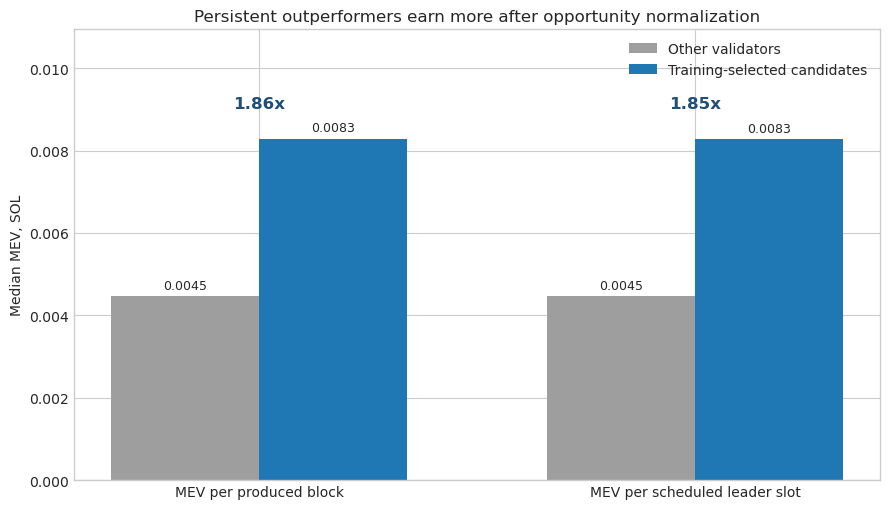

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

labels = ["MEV per produced block", "MEV per scheduled leader slot"]
other = [
    metrics["other_median_mev_per_produced_block"],
    metrics["other_median_mev_per_scheduled_slot"],
]
candidate = [
    metrics["candidate_median_mev_per_produced_block"],
    metrics["candidate_median_mev_per_scheduled_slot"],
]
ratios = [metrics["candidate_block_ratio"], metrics["candidate_slot_ratio"]]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5.2))
bars_other = ax.bar(x - width / 2, other, width, label="Other validators", color="#9E9E9E")
bars_candidate = ax.bar(x + width / 2, candidate, width, label="Training-selected candidates", color="#1F77B4")

for bars in [bars_other, bars_candidate]:
    for bar in bars:
        val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.00018, f"{val:.4f}", ha="center", fontsize=9)

for i, ratio in enumerate(ratios):
    ax.text(i, max(other[i], candidate[i]) + 0.00075, f"{ratio:.2f}x", ha="center", fontsize=12, fontweight="bold", color="#1F4E78")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Median MEV, SOL")
ax.set_title("Persistent outperformers earn more after opportunity normalization")
ax.legend(frameon=False)
ax.set_ylim(0, max(candidate) * 1.32)
plt.tight_layout()
plt.show()


## Key plot 2 — mechanism attribution

,mechanism,evidence_strength,incremental_r2_vs_stake_baseline,r2_loss_when_dropped_from_full,candidate_attenuation_vs_stake_baseline,status
0,Latency / infra / reliability,partial / indirect,0.039286,0.011629,-0.020472,partially tested
1,Private order-flow / searcher-flow,strongest among available proxies,0.063484,0.030987,-0.102965,strongest current proxy family
2,Bundle outcome / landed execution,partial / landed-only,0.045148,0.014281,-0.524571,partially tested
3,Entity / vertical integration,weak / suggestive,0.017143,0.013075,0.096508,weak proxy only


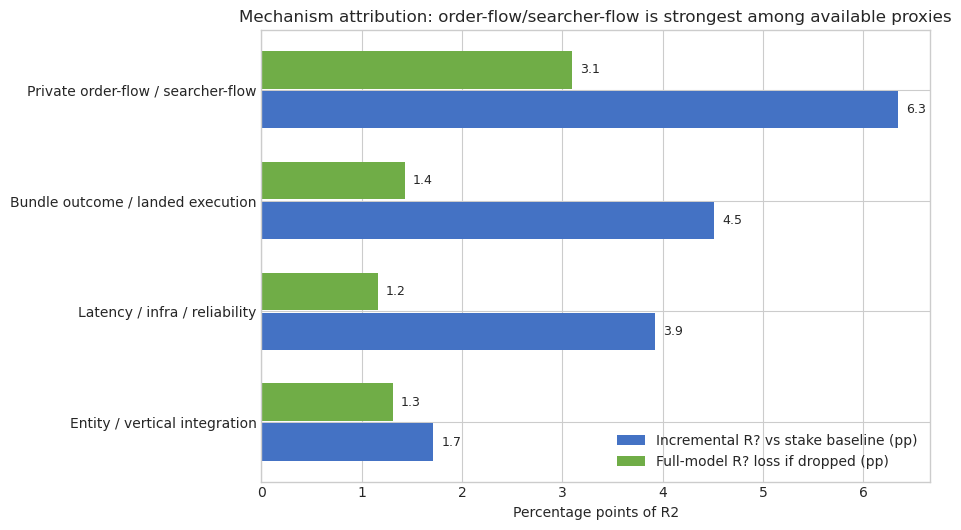

In [4]:
mechanism_display = attrib[[
    "mechanism",
    "evidence_strength",
    "incremental_r2_vs_stake_baseline",
    "r2_loss_when_dropped_from_full",
    "candidate_attenuation_vs_stake_baseline",
    "status",
]].copy()

display(mechanism_display)

plot_df = attrib.sort_values("incremental_r2_vs_stake_baseline").copy()
plot_df["incremental_pp"] = plot_df["incremental_r2_vs_stake_baseline"] * 100
plot_df["drop_loss_pp"] = plot_df["r2_loss_when_dropped_from_full"] * 100

fig, ax = plt.subplots(figsize=(9.5, 5.4))
y = np.arange(len(plot_df))
ax.barh(y - 0.18, plot_df["incremental_pp"], height=0.34, label="Incremental R? vs stake baseline (pp)", color="#4472C4")
ax.barh(y + 0.18, plot_df["drop_loss_pp"], height=0.34, label="Full-model R? loss if dropped (pp)", color="#70AD47")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["mechanism"])
ax.set_xlabel("Percentage points of R2")
ax.set_title("Mechanism attribution: order-flow/searcher-flow is strongest among available proxies")
ax.legend(frameon=False, loc="lower right")

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.incremental_pp + 0.08, i - 0.18, f"{row.incremental_pp:.1f}", va="center", fontsize=9)
    ax.text(row.drop_loss_pp + 0.08, i + 0.18, f"{row.drop_loss_pp:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## Validity checks

In [5]:
validity_rows = []

validity_rows.append({
    "Check": "Completed epochs",
    "Result": metrics["completed_epochs"],
    "Interpretation": "Uses ten completed epochs and excludes the current incomplete epoch.",
})
validity_rows.append({
    "Check": "Final benchmark sample",
    "Result": f"N={int(s['benchmark_n'])}",
    "Interpretation": "Final sample-preserving model is comparable to v20 and avoids a redundant skipped-slots proxy with missing values.",
})
validity_rows.append({
    "Check": "Final benchmark fit",
    "Result": f"R?={s['benchmark_r_squared']:.3f}, adjusted R?={s['benchmark_adj_r_squared']:.3f}",
    "Interpretation": "High-fit benchmark used for mechanism attribution.",
})
validity_rows.append({
    "Check": "Candidate coefficient",
    "Result": f"coef={s['benchmark_candidate_coef']:.3f}, p={s['benchmark_candidate_p']:.4f}",
    "Interpretation": "Persistent candidate edge remains visible after observable controls.",
})
validity_rows.append({
    "Check": "Data-loss audit",
    "Result": "; ".join(audit["finding"].astype(str).head(4)),
    "Interpretation": "No validator-row loss or key mismatch in the local diagnostic.",
})
validity_rows.append({
    "Check": "v20-to-v21 drift",
    "Result": "; ".join(drift["status"].astype(str).unique()),
    "Interpretation": "The final v21 result stays within tolerance of the older v20 benchmark and preserves the same mechanism ranking.",
})

cjk = re.compile(r"[\u4e00-\u9fff]")
english_only = True
for path in [FULL_NOTEBOOK, DATA_DOC, API_DOC]:
    if path.exists() and cjk.search(path.read_text(encoding="utf-8", errors="ignore")):
        english_only = False
with zipfile.ZipFile(V21_XLSX) as zf:
    for name in zf.namelist():
        if name.endswith(".xml") and cjk.search(zf.read(name).decode("utf-8", errors="ignore")):
            english_only = False
            break
validity_rows.append({
    "Check": "English-only deliverables",
    "Result": english_only,
    "Interpretation": "The v21 notebook, workbook, and companion docs were scanned for Chinese characters.",
})

validity = pd.DataFrame(validity_rows)
display(validity)

assert int(s["benchmark_n"]) == 411
assert s["benchmark_r_squared"] > 0.80
assert set(drift["status"]).issubset({"WITHIN_TOLERANCE", "SAME"})
assert english_only is True


,Check,Result,Interpretation
0,Completed epochs,983-992,Uses ten completed epochs and excludes the cur...
1,Final benchmark sample,N=411,Final sample-preserving model is comparable to...
2,Final benchmark fit,"R?=0.816, adjusted R?=0.781",High-fit benchmark used for mechanism attribut...
3,Candidate coefficient,"coef=0.316, p=0.0014",Persistent candidate edge remains visible afte...
4,Data-loss audit,no row loss in local diagnostic; same column c...,No validator-row loss or key mismatch in the l...
5,v20-to-v21 drift,WITHIN_TOLERANCE; SAME,The final v21 result stays within tolerance of...
6,English-only deliverables,True,"The v21 notebook, workbook, and companion docs..."


## Final interpretation and caveats

The result is **not** a simple yes/no. The aggregate auction allocation looks broadly compatible with stake and leader opportunity, so I would not describe Jito as a simple winner-take-all rent machine based only on concentration.

However, the validator-level evidence is stronger: early outperformers keep earning more MEV per produced block and per scheduled leader slot in later epochs, and the edge remains visible after observable controls. The strongest available mechanism proxy is order-flow/searcher-flow; landed-execution and latency/infra proxies are partial; entity/vertical integration remains suggestive but not proven.

### What this does not prove

This notebook does not prove private searcher-validator relationships, raw latency advantage, ownership/vertical integration, rejected-bundle dynamics, or the causal effect of any one mechanism. Those claims would require bundle IDs, searcher identity, validator-searcher pairing history, relay timestamps, raw latency distributions, and operator/ownership mapping.

### Files behind this short notebook

- `clean_analysis_reviewed_improved_v21.ipynb`: full reproducible notebook.
- `jito_analysis_reviewed_improved_v21.xlsx`: final tables, dashboard, mechanism attribution, and validity checks.
- `clean_analysis_reviewed_improved_v21_data_variables.md`: variable definitions and construction notes.
- `clean_analysis_reviewed_improved_v21_api_acquisition.md`: API acquisition notes and limitations.


## Appendix: Original statistical tables

These are the original statistical tables supporting the conclusion. They are placed here as appendix material so the main write-up stays answer-first.

### Appendix Table A1. Main model statistics: how R^2 builds up

| Model | N | Variables | R^2 | Adjusted R^2 | Delta R^2 vs previous | Candidate coef. | Candidate p-value |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Opportunity controls only | 411 | 3 | 0.164 | 0.158 |  | 0.687 | 9.985e-26 |
| Opportunity + stake-side controls | 411 | 10 | 0.702 | 0.695 | 0.538 | 0.257 | 1.572e-08 |
| Final benchmark with all observable proxies | 411 | 65 | 0.816 | 0.781 | 0.113 | 0.316 | 0.00143 |

**How to read Table A1:** the model fit rises from opportunity controls only to stake-side controls, and then to the final benchmark with observable mechanism proxies. The final benchmark remains high-fit and the candidate coefficient remains statistically significant.

### Appendix Table A2. Four-mechanism statistics: R^2 contribution and candidate-edge attenuation

| Mechanism family | Variables | Module-only R^2 | R^2 after adding to stake baseline | Incremental R^2 vs stake baseline | R^2 loss if dropped from full model | Candidate attenuation vs stake baseline | Evidence strength |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Latency / infra / reliability | 11 | 0.346 | 0.742 | 0.039 | 0.012 | -0.020 | partial / indirect |
| Private order-flow / searcher-flow | 18 | 0.501 | 0.766 | 0.063 | 0.031 | -0.103 | strongest among available proxies |
| Bundle outcome / landed execution | 18 | 0.350 | 0.748 | 0.045 | 0.014 | -0.525 | partial / landed-only |
| Entity / vertical integration | 6 | 0.251 | 0.720 | 0.017 | 0.013 | 0.097 | weak / suggestive |

**How to read Table A2:** order-flow/searcher-flow has the largest incremental R^2 and the largest full-model R^2 loss when dropped, so it is the strongest available observable mechanism proxy. Entity/vertical integration has positive candidate attenuation, but it remains weak/suggestive because ownership and private relationship data are not observed.


In [6]:
# Code used to reconstruct the appendix statistical tables from the v21 workbook.
module_models = pd.read_excel(V21_XLSX, sheet_name="04_module_models")

appendix_main_stats = []
main_order = ["M0", "M1", "M_FULL"]
main_labels = {
    "M0": "Opportunity controls only",
    "M1": "Opportunity + stake-side controls",
    "M_FULL": "Final benchmark with all observable proxies",
}
previous_r2 = None
for model_id in main_order:
    row = module_models.loc[module_models["model_id"].eq(model_id)].iloc[0]
    r2 = float(row["r_squared"])
    appendix_main_stats.append({
        "Model": main_labels[model_id],
        "N": int(row["n"]),
        "Variables": int(row["n_variables_ex_const"]),
        "R^2": r2,
        "Adjusted R^2": float(row["adj_r_squared"]),
        "Delta R^2 vs previous": np.nan if previous_r2 is None else r2 - previous_r2,
        "Candidate coef.": float(row["candidate_coef"]),
        "Candidate p-value": float(row["candidate_p"]),
    })
    previous_r2 = r2
appendix_main_stats = pd.DataFrame(appendix_main_stats)

def fmt_p(x):
    return f"{x:.4g}" if pd.notna(x) else ""

appendix_mechanism_stats = attrib[[
    "mechanism", "n_H7_variables", "module_only_r_squared",
    "add_to_stake_baseline_r_squared", "incremental_r2_vs_stake_baseline",
    "r2_loss_when_dropped_from_full", "candidate_attenuation_vs_stake_baseline",
    "evidence_strength",
]].copy().rename(columns={
    "mechanism": "Mechanism family",
    "n_H7_variables": "Variables",
    "module_only_r_squared": "Module-only R^2",
    "add_to_stake_baseline_r_squared": "R^2 after adding to stake baseline",
    "incremental_r2_vs_stake_baseline": "Incremental R^2 vs stake baseline",
    "r2_loss_when_dropped_from_full": "R^2 loss if dropped from full model",
    "candidate_attenuation_vs_stake_baseline": "Candidate attenuation vs stake baseline",
    "evidence_strength": "Evidence strength",
})

display(Markdown("### Appendix Table A1 reproduced by code"))
display(appendix_main_stats.style.format({
    "R^2": "{:.3f}",
    "Adjusted R^2": "{:.3f}",
    "Delta R^2 vs previous": "{:.3f}",
    "Candidate coef.": "{:.3f}",
    "Candidate p-value": fmt_p,
}))

display(Markdown("### Appendix Table A2 reproduced by code"))
display(appendix_mechanism_stats.style.format({
    "Module-only R^2": "{:.3f}",
    "R^2 after adding to stake baseline": "{:.3f}",
    "Incremental R^2 vs stake baseline": "{:.3f}",
    "R^2 loss if dropped from full model": "{:.3f}",
    "Candidate attenuation vs stake baseline": "{:.3f}",
}))


### Appendix Table A1 reproduced by code

,Model,N,Variables,R^2,Adjusted R^2,Delta R^2 vs previous,Candidate coef.,Candidate p-value
0,Opportunity controls only,411,3,0.164,0.158,nan,0.687,9.985e-26
1,Opportunity + stake-side controls,411,10,0.702,0.695,0.538,0.257,1.572e-08
2,Final benchmark with all observable proxies,411,65,0.816,0.781,0.113,0.316,0.00143


### Appendix Table A2 reproduced by code

,Mechanism family,Variables,Module-only R^2,R^2 after adding to stake baseline,Incremental R^2 vs stake baseline,R^2 loss if dropped from full model,Candidate attenuation vs stake baseline,Evidence strength
0,Latency / infra / reliability,11,0.346,0.742,0.039,0.012,-0.020,partial / indirect
1,Private order-flow / searcher-flow,18,0.501,0.766,0.063,0.031,-0.103,strongest among available proxies
2,Bundle outcome / landed execution,18,0.350,0.748,0.045,0.014,-0.525,partial / landed-only
3,Entity / vertical integration,6,0.251,0.720,0.017,0.013,0.097,weak / suggestive
